In [1]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

Parent directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Using device: cuda
Number of CPUs available: 128


In [2]:
# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 2

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 2                                                   # Number of inputs
species_labels = ['X_1', 'Z_1', 'Z_2']                  # Species labels
mak_order = 2                                           # Maximum order of the mass-action reactions

# Time horizon for the simulation
t_f = 100                                               # Final time for the simulation
N_t = 1000                                              # Number of time steps in the simulation
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
nums = [0.5, 1.0, 1.5]
u_list = [np.array(u) for u in product(nums, repeat=p)] # list of input combinations, each input is a numpy array of shape (p,)

# Construct the reference setpoints
r_list = [np.array([u[0]]) for u in u_list]

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0, 0.0, 0.0]])

# Construct the weights for the performance metric
w = np.ones(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
w = w[np.newaxis, :]

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)                                                # Number of time steps

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(os.getcwd(), '..', 'hof'))
base_path_models = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

Current working directory: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/plots
Base path for halls of fame: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/hof
Base path for models: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/models


In [3]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")

# Collect all IOCRNs into a single list
all_iocrns = hof_iocrns.copy()
if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")

Found 7 hall of fame files:
- hall_of_fame_2025-11-21 12:50:07.pth
- hall_of_fame_2025-11-21 15:48:38.pth
- hall_of_fame_2025-11-21 14:05:27.pth
- hall_of_fame_2025-11-21 15:03:26.pth
- hall_of_fame_2025-11-21 23:24:40.pth
- hall_of_fame_2025-11-21 16:22:07.pth
- hall_of_fame_2025-11-21 13:32:33.pth
----------------------------------------
Found 1 generated files:
- generated_2025-11-21 16:22:07.pth
----------------------------------------
Loaded hall_of_fame_2025-11-21 12:50:07.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 15:48:38.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 14:05:27.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 15:03:26.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 23:24:40.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 16:22:07.pth with 30 entries.
Loaded hall_of_fame_2025-11-21 13:32:33.pth with 30 entries.
----------------------------------------
Total IOCRNs collected from all halls of fame: 210
-------------------------------------

In [4]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 1181 out of 1490 total IOCRNs.


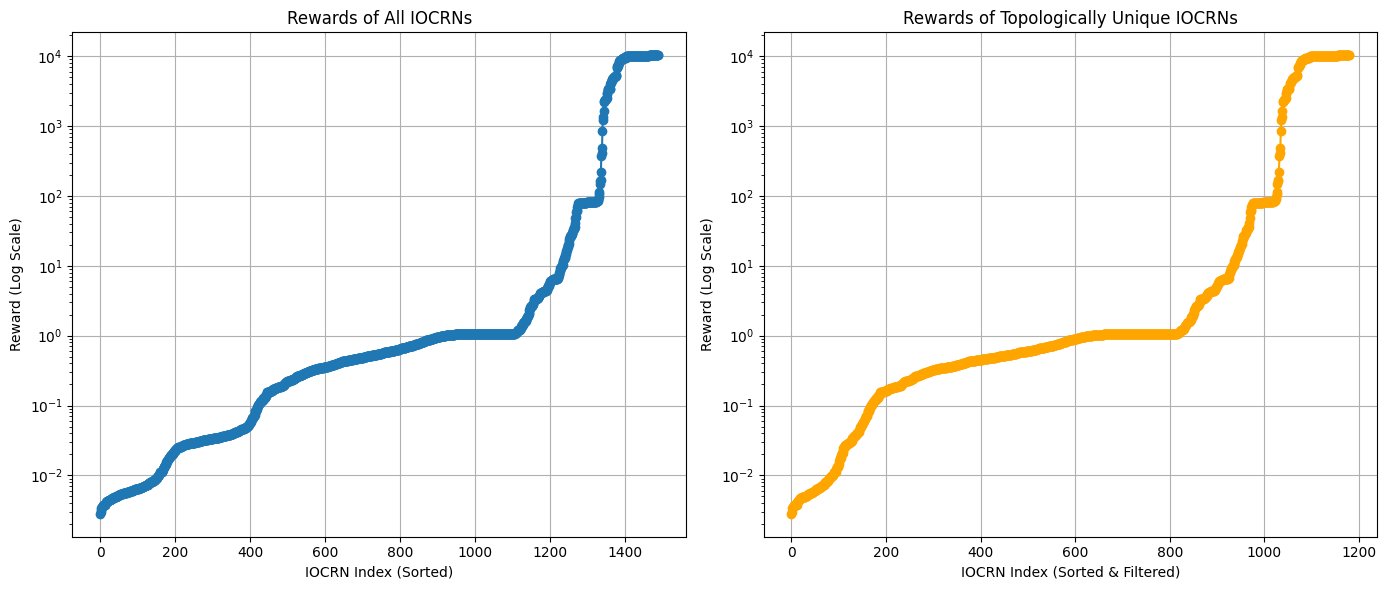

In [5]:
# Sort all IOCRNs by reward, filter topologically unique ones, and plot rewards
# Sort all IOCRNs by reward
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'])  

# Filter topologically unique IOCRNs 
if filter_flag:
    print("Filtering topologically unique IOCRNs...")
    all_iocrns_sorted_filtered = []
    all_iocrns_sorted_filtered.append(all_iocrns_sorted[0])
    for i in range(1, len(all_iocrns_sorted)):
        for j in range(len(all_iocrns_sorted_filtered)):
            if all_iocrns_sorted[i].is_topologically_equal(all_iocrns_sorted_filtered[j]):
                found = True
                break
        else:
            found = False
        if not found:
            all_iocrns_sorted_filtered.append(all_iocrns_sorted[i])
    print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

else:
    all_iocrns_sorted_filtered = all_iocrns_sorted

# Plot the rewards of the sorted and sorted-filtered IOCRNs
rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(rewards_sorted, marker='o')
ax1.set_yscale('log')
ax1.set_xlabel('IOCRN Index (Sorted)')
ax1.set_ylabel('Reward (Log Scale)')
ax1.set_title('Rewards of All IOCRNs')
ax1.grid(True)
ax2.plot(rewards_sorted_filtered, marker='o', color='orange')
ax2.set_yscale('log')
ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
ax2.set_ylabel('Reward (Log Scale)')
ax2.set_title('Rewards of Topologically Unique IOCRNs')
ax2.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 400
n_filtered = 150

Unfiltered: IOCRN # 400 has a reward of 0.05687873896428024


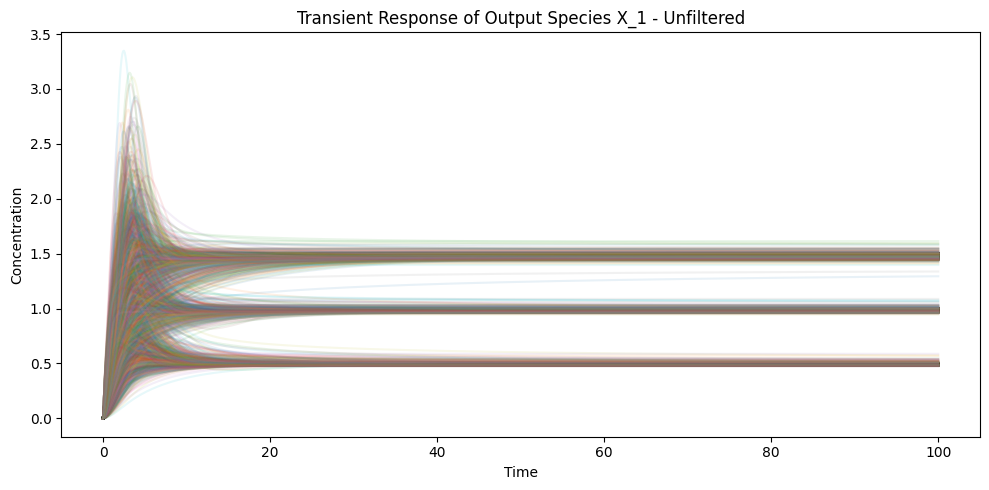

In [7]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

Filtered: IOCRN # 150 has a reward of 0.0519926126821464


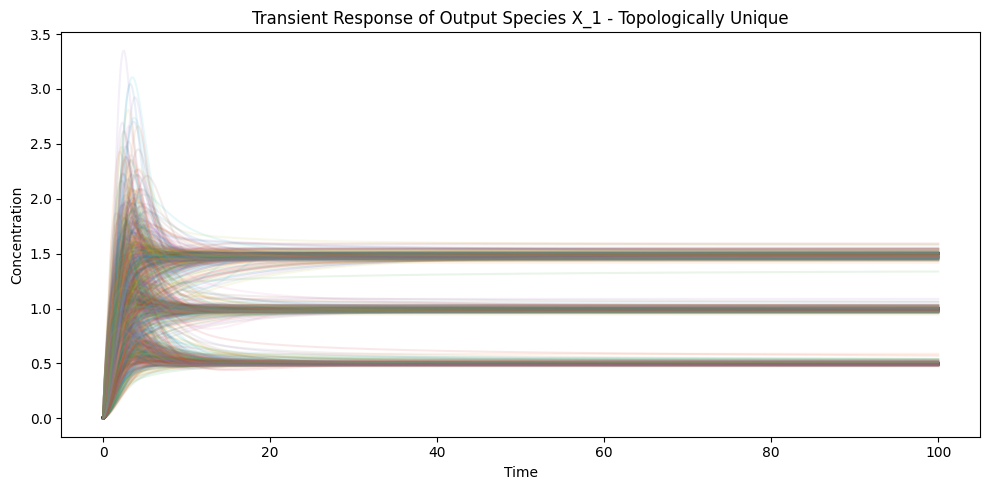

In [8]:
# Plot the responses of the top topologically unique IOCRNs
ax = None
for i in range(n_filtered):
    x0_list = ic.get_ic(all_iocrns_sorted_filtered[i])
    fig, ax = all_iocrns_sorted_filtered[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Topologically Unique')
print(f'Filtered: IOCRN # {n_filtered} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

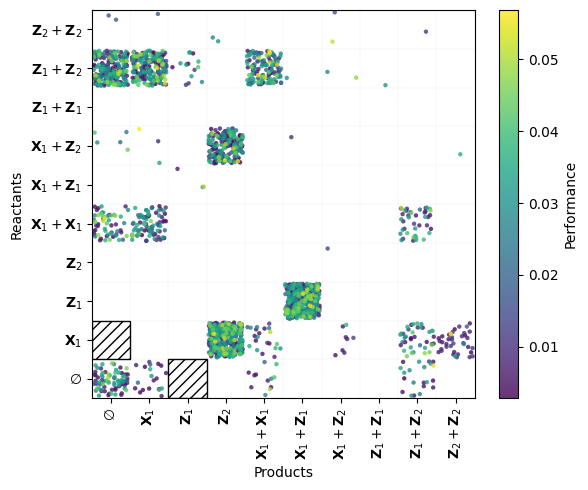

In [9]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
plot_reactant_product_scatter(
    all_iocrns_sorted[0:n_unfiltered],
    perf=rewards_sorted[0:n_unfiltered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=20,
    figsize=(6, 5),
    jitter_scale=0.45,
)

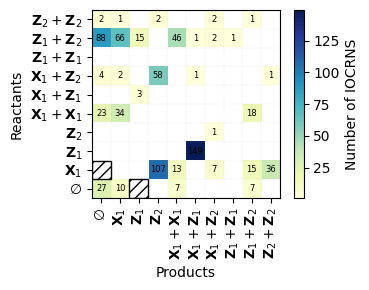

In [10]:
# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(4, 3),
)

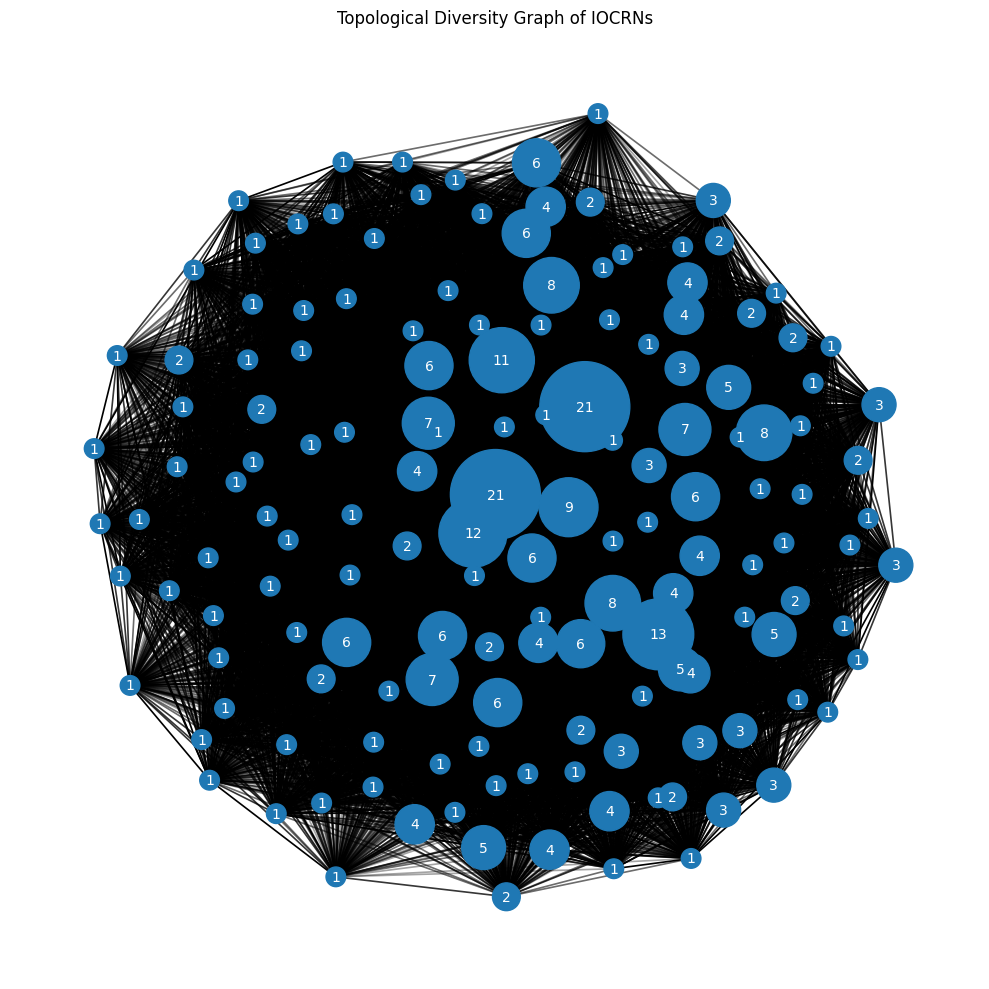

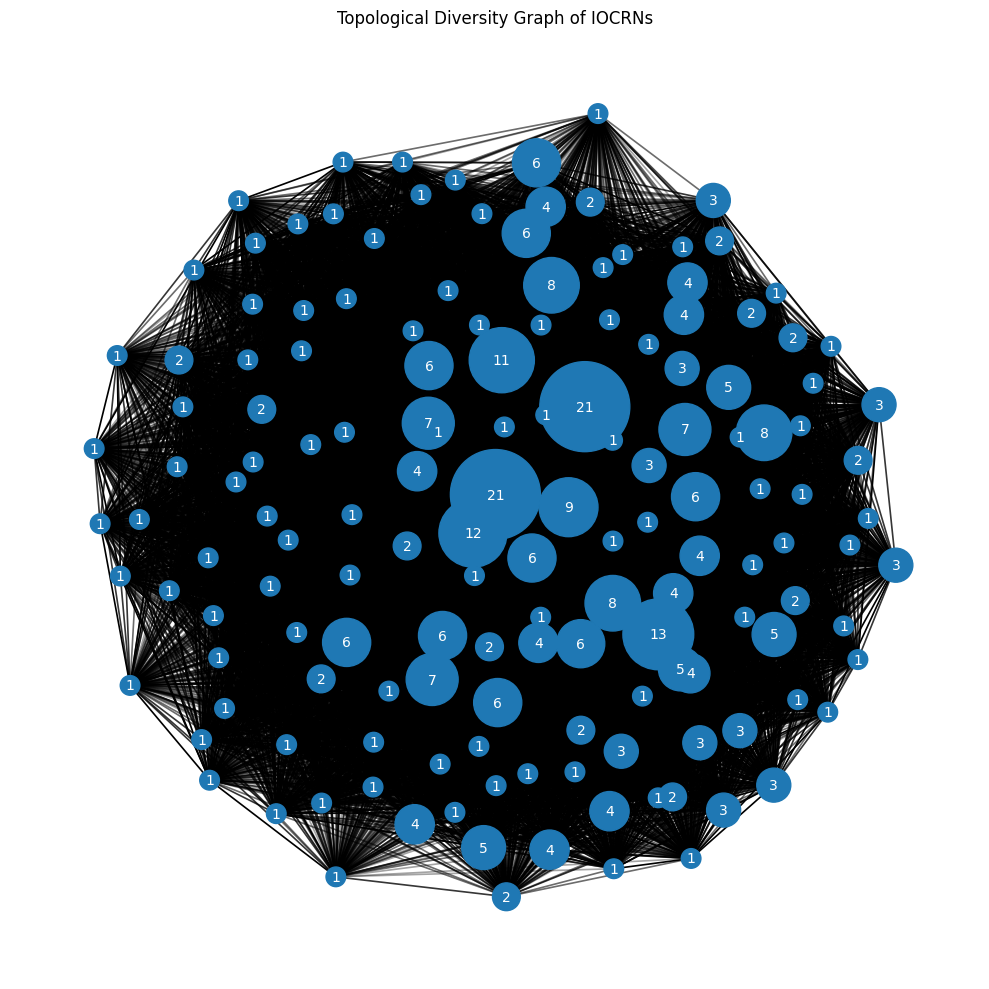

In [12]:
# Graphs showing different topologies and connectivity and numbers in circles and colors corresponding to rewards.
topology_graph(all_iocrns_sorted[:n_unfiltered], t=10, figsize = (10,10))